# Time Series Naive
**Author:** Alejandro Orellana

**Date:** Feburary 4, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score

from utils.data_utils import load_data, load_neighborhood_geojson
from utils.fix_effect_utils import prepared_dataframe

geojson_data = load_neighborhood_geojson()
analysis_df = prepared_dataframe(load_data())
target_col = "Site EUI (kBtu/sq ft)"

2026-02-09 04:58:26,582 [INFO] Loading GeoJSON from: /project/data/chicago_geo/neighborhood_chi.geojson
2026-02-09 04:58:26,639 [INFO] Loaded 98 features
2026-02-09 04:58:27,171 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-02-09 04:58:27,173 [INFO] Category counts:
COVID Impact Category
Other                   505
Permanent              1813
Stable/Increased       7470
Temporary/Rebounded    1716


In [ ]:
missing_counts = analysis_df.groupby("ID").agg(
    Missing_Data=("Site EUI (kBtu/sq ft)", lambda x: x.isna().sum())
)

dropping_list = missing_counts[missing_counts["Missing_Data"] > 0].index
model_data = analysis_df.copy()
print(f"Orignal # of buildings: {len(model_data.ID.unique())}")
model_data = model_data.drop(model_data[model_data["ID"].isin(dropping_list)].index)
print(f"New # of full history buildings: {len(model_data.ID.unique())}")
model_data = model_data.sort_values(["ID", "Data Year"])
model_data = model_data[model_data["Primary Property Type"] == "multifamily housing"]
print(f"New # of multifamily housing buildings: {len(model_data.ID.unique())}")

Orignal # of buildings: 1280
New # of full history buildings: 1214
New # of multifamily housing buildings: 716


In [ ]:
remove_year = 2016
cut_off_year = 2023
model_data["Site_EUI_Lag1"] = model_data.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(1)

model_data = model_data[model_data["Data Year"] != remove_year]

train_df = model_data[model_data["Data Year"] < cut_off_year]
test_df = model_data[model_data["Data Year"] == cut_off_year]
print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")
print(model_data["Data Year"].unique())
model_data[["Data Year", "ID", "Site EUI (kBtu/sq ft)", "Site_EUI_Lag1"]].head()

Training Samples: 4296 | Testing Samples: 716
[2017 2018 2019 2020 2021 2022 2023]


,Data Year,ID,Site EUI (kBtu/sq ft),Site_EUI_Lag1
2223,2017,100211,141.1,92.5
26699,2018,100211,73.6,141.1
20015,2019,100211,71.6,73.6
3943,2020,100211,75.0,71.6
13601,2021,100211,73.8,75.0


In [ ]:
naive_preds = test_df["Site_EUI_Lag1"]
naive_rmse = np.sqrt(mean_squared_error(test_df[target_col], naive_preds))
print("--- Benchmark: Naive ---")
print(f"RMSE (Error): {naive_rmse:.4f}")

formula = "Q('Site EUI (kBtu/sq ft)') ~ Site_EUI_Lag1"

model = smf.ols(formula, data=train_df).fit()

print(model.summary())

--- Benchmark: Naive ---
RMSE (Error): 11.8401
                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.649
Model:                                    OLS   Adj. R-squared:                  0.649
Method:                         Least Squares   F-statistic:                     7941.
Date:                        Mon, 09 Feb 2026   Prob (F-statistic):               0.00
Time:                                04:58:27   Log-Likelihood:                -17621.
No. Observations:                        4296   AIC:                         3.525e+04
Df Residuals:                            4294   BIC:                         3.526e+04
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-

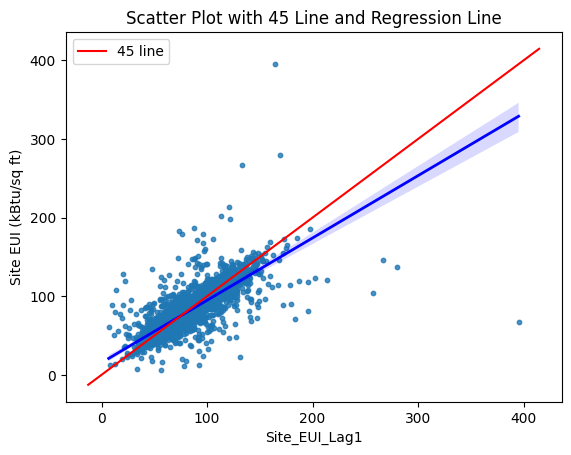

In [ ]:
sns.regplot(
    data=model_data,
    x="Site_EUI_Lag1",
    y="Site EUI (kBtu/sq ft)",
    scatter_kws={"s": 10},
    line_kws={"color": "blue", "linewidth": 2},
)

x_lim = plt.xlim()
y_lim = plt.ylim()
min_val = min(x_lim[0], y_lim[0])
max_val = max(x_lim[1], y_lim[1])
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="45 line")

plt.title("Scatter Plot with 45 Line and Regression Line")
plt.legend()
plt.show()

In [ ]:
test_df["Predicted_EUI"] = model.predict(test_df)
model_rmse = np.sqrt(mean_squared_error(test_df[target_col], test_df["Predicted_EUI"]))
model_r2 = r2_score(test_df[target_col], test_df["Predicted_EUI"])

print("\n--- Validation Results (2022-2023) ---")
print(f"Model RMSE: {model_rmse:.4f} (Lower is better)")
print(f"Model R2:   {model_r2:.4f} (Higher is better)")

improvement = naive_rmse - model_rmse
if improvement > 0:
    print(f"SUCCESS: Model beat the naive baseline by {improvement:.4f} EUI units.")
else:
    print("Model failed to beat naive baseline.")
test_df[
    ["Data Year", "ID", "Site EUI (kBtu/sq ft)", "Site_EUI_Lag1", "Predicted_EUI"]
].head(12)


--- Validation Results (2022-2023) ---
Model RMSE: 10.8305 (Lower is better)
Model R2:   0.7117 (Higher is better)
SUCCESS: Model beat the naive baseline by 1.0096 EUI units.


/tmp/ipykernel_9685/1294519066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted_EUI'] = model.predict(test_df)


,Data Year,ID,Site EUI (kBtu/sq ft),Site_EUI_Lag1,Predicted_EUI
18332,2023,100211,48.3,91.1,88.705959
19145,2023,100346,41.1,43.9,51.254120
17711,2023,100375,93.0,82.3,81.723413
19258,2023,100438,113.0,127.1,117.270921
17875,2023,100485,77.5,89.1,87.119017
19177,2023,101030,52.6,55.3,60.299691
18555,2023,101032,99.7,121.0,112.430747
16606,2023,101090,90.9,102.6,97.830877
19504,2023,101217,61.4,78.9,79.025611
18591,2023,101226,57.6,65.0,67.996362


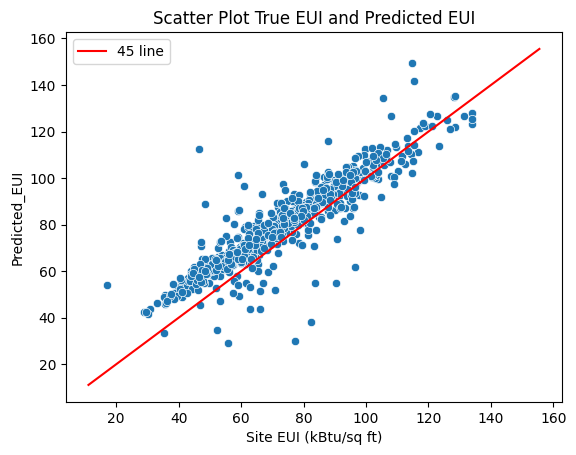

In [ ]:
sns.scatterplot(data=test_df, y="Predicted_EUI", x="Site EUI (kBtu/sq ft)")

x_lim = plt.xlim()
y_lim = plt.ylim()
min_val = min(x_lim[0], y_lim[0])
max_val = max(x_lim[1], y_lim[1])
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="45 line")

plt.title("Scatter Plot True EUI and Predicted EUI")
plt.legend()
plt.show()